<img src = "https://drive.google.com/uc?export=view&id=1Hh_G3M13P9xSNgSiQ-WnALg93XwK_hG8" alt = "Encabezado MLDS" width = "100%">  </img>

# **Entrenamiento y Validación**
---


## **0. Integrantes del equipo de trabajo**
---

1. Ivonne Alexandra Guevara Prieto - CC 1032376081

## **Setup: Librerías, semillas y recarga de modelos**
---

Recargamos librerías, semillas, datos y reconstruimos los dos modelos definidos previamente.

In [2]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import os, random
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
import seaborn as sns
%matplotlib inline
plt.style.use("ggplot")

# Configuración de semillas para reproducibilidad
random.seed(0)
keras.utils.set_random_seed(0)
tf.random.set_seed(0)
np.random.seed(0)

import warnings
warnings.filterwarnings('ignore')

In [3]:
import kagglehub

path       = kagglehub.dataset_download("robinreni/signature-verification-dataset")
base_path  = path
train_path = os.path.join(base_path, "sign_data/train")
test_path  = os.path.join(base_path, "sign_data/test")

train_csv = pd.read_csv(os.path.join(base_path, "sign_data/train_data.csv"), header=None)
test_csv  = pd.read_csv(os.path.join(base_path, "sign_data/test_data.csv"),  header=None)
train_csv.rename(columns={0: 'image_original_name', 1: 'image_comparison_name', 2: 'label'}, inplace=True)
test_csv.rename( columns={0: 'image_original_name', 1: 'image_comparison_name', 2: 'label'}, inplace=True)

print("Dataset cargado.")

100%|██████████| 601M/601M [00:34<00:00, 18.3MB/s]

Extracting files...


Dataset cargado.


In [4]:
def preprocesar_imagen(ruta_img, tam=(105, 105)):
    img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, tam)
    img = img / 255.0
    return img.reshape(tam[0], tam[1], 1)

def construir_pares_desde_csv(df, base_img_folder):
    pares, labels = [], []
    omitidos = 0
    for _, row in df.iterrows():
        ruta_a = os.path.join(base_img_folder, row['image_original_name'])
        ruta_b = os.path.join(base_img_folder, row['image_comparison_name'])
        if os.path.exists(ruta_a) and os.path.exists(ruta_b):
            pares.append([preprocesar_imagen(ruta_a), preprocesar_imagen(ruta_b)])
            labels.append(row['label'])
        else:
            omitidos += 1
    print(f"  Pares construidos: {len(pares)} | Omitidos: {omitidos}")
    return np.array(pares), np.array(labels)

print("Construyendo pares de entrenamiento...")
pares_train, labels_train = construir_pares_desde_csv(train_csv, train_path)
print("Construyendo pares de prueba...")
pares_test, labels_test   = construir_pares_desde_csv(test_csv,  test_path)

# Partición train / validación (misma semilla que M5U4)
pares_tr, pares_val, labels_tr, labels_val = train_test_split(
    pares_train, labels_train,
    test_size=0.2, random_state=42, stratify=labels_train
)

print(f"\nTrain: {len(pares_tr)} | Val: {len(pares_val)} | Test: {len(pares_test)}")

Construyendo pares de entrenamiento...
  Pares construidos: 23206 | Omitidos: 0
Construyendo pares de prueba...
  Pares construidos: 5748 | Omitidos: 0

Train: 18564 | Val: 4642 | Test: 5748


In [5]:
# Reconstrucción de los modelos definidos en M5U4
INPUT_SHAPE = (105, 105, 1)

# Data augmentation
data_augmentation = keras.Sequential(
    [
        keras.layers.Input(shape=INPUT_SHAPE),
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(factor=0.05),
        keras.layers.RandomZoom(height_factor=0.05, width_factor=0.05),
    ],
    name="data_augmentation"
)

# ── MODELO 1: CNN base ────────────────────────────────────────────────────
def construir_red_base():
    red_base = keras.models.Sequential(name='red_base')
    red_base.add(keras.layers.Input(shape=INPUT_SHAPE))
    red_base.add(data_augmentation)
    red_base.add(keras.layers.Conv2D(filters=64,  kernel_size=(10, 10), activation='relu'))
    red_base.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
    red_base.add(keras.layers.Dropout(0.3))
    red_base.add(keras.layers.Conv2D(filters=128, kernel_size=(7, 7),  activation='relu'))
    red_base.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
    red_base.add(keras.layers.Dropout(0.3))
    red_base.add(keras.layers.Conv2D(filters=128, kernel_size=(4, 4),  activation='relu'))
    red_base.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
    red_base.add(keras.layers.Flatten())
    red_base.add(keras.layers.Dense(units=4096, activation='sigmoid'))
    return red_base

red_base    = construir_red_base()
entrada_a   = keras.layers.Input(shape=INPUT_SHAPE, name='firma_referencia')
entrada_b   = keras.layers.Input(shape=INPUT_SHAPE, name='firma_sospechosa')
embedding_a = red_base(entrada_a)
embedding_b = red_base(entrada_b)
distancia_L1 = keras.layers.Lambda(
    lambda tensors: keras.ops.abs(tensors[0] - tensors[1]),
    name='distancia_L1'
)([embedding_a, embedding_b])
salida = keras.layers.Dense(units=1, activation='sigmoid', name='clasificador')(distancia_L1)
modelo_siames = keras.models.Model(
    inputs=[entrada_a, entrada_b], outputs=salida, name='Red_Siamesa_CNN'
)

# ── MODELO 2: EfficientNetB0 ──────────────────────────────────────────────
extractor = keras.applications.EfficientNetB0(
    weights='imagenet', include_top=False, input_shape=(105, 105, 3)
)
for layer in extractor.layers:
    layer.trainable = False

def construir_red_base_efficientnet():
    entradas = keras.layers.Input(shape=INPUT_SHAPE, name='entrada_efficientnet')
    x = keras.layers.Conv2D(filters=3, kernel_size=(1, 1), padding='same', name='canal_adapter')(entradas)
    x = extractor(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(units=512, activation='relu')(x)
    x = keras.layers.Dropout(0.3)(x)
    x = keras.layers.Dense(units=4096, activation='sigmoid', name='embedding')(x)
    return keras.models.Model(entradas, x, name='red_base_efficientnet')

red_base_eff    = construir_red_base_efficientnet()
entrada_a_eff   = keras.layers.Input(shape=INPUT_SHAPE, name='firma_referencia_eff')
entrada_b_eff   = keras.layers.Input(shape=INPUT_SHAPE, name='firma_sospechosa_eff')
embedding_a_eff = red_base_eff(entrada_a_eff)
embedding_b_eff = red_base_eff(entrada_b_eff)
distancia_L1_eff = keras.layers.Lambda(
    lambda tensors: keras.ops.abs(tensors[0] - tensors[1]),
    name='distancia_L1_eff'
)([embedding_a_eff, embedding_b_eff])
salida_eff = keras.layers.Dense(units=1, activation='sigmoid', name='clasificador_eff')(distancia_L1_eff)
modelo_siames_eff = keras.models.Model(
    inputs=[entrada_a_eff, entrada_b_eff], outputs=salida_eff, name='Red_Siamesa_EfficientNet'
)

print("Modelos reconstruidos correctamente.")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Modelos reconstruidos correctamente.


## **1. Entrenamiento del Modelo y Selección de Hiperparámetros**
---

### **1.1. Estrategia de selección de hiperparámetros**
---

Se compararán **dos configuraciones de learning rate** para cada modelo, siguiendo una búsqueda manual en cuadrícula (*grid search* manual). Los demás hiperparámetros se fijan:

---

| Hiperparámetro | Valor fijo | Justificación |
|---|---|---|
| batch_size | 32 | Balance entre estabilidad del gradiente y uso de memoria en Colab T4 |
| epochs | 30 | Suficiente para convergencia con EarlyStopping activo |
| optimizer | Adam | Convergencia rápida y adaptación del learning rate por parámetro |
| loss | binary_crossentropy | Estándar para clasificación binaria |

---

| Configuración | Learning rate | Descripción |
|---|---|---|
| **Config A** | 1e-4 | Valor inicial |
| **Config B** | 1e-5 | Learning rate más conservador para evitar sobreajuste |

### **1.2. Callbacks de entrenamiento**
---

Definimos los callbacks que controlarán el entrenamiento de ambos modelos:

In [6]:
def construir_callbacks(nombre_modelo):
    """
    Construye los callbacks de entrenamiento para un modelo dado.
    - EarlyStopping: detiene el entrenamiento si val_auc no mejora en 5 épocas.
    - ModelCheckpoint: guarda el mejor modelo según val_auc.
    - ReduceLROnPlateau: reduce el learning rate si val_loss se estanca.
    """
    return [
        keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=5,
            mode='max',
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=f'{nombre_modelo}_mejor.keras',
            monitor='val_auc',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]

### **1.3. Entrenamiento del Modelo 1 — Red Siamesa CNN base**
---

In [7]:
# ── CONFIG A: lr = 1e-4 ───────────────────────────────────────────────────
print("Entrenando Modelo 1 — Config A (lr=1e-4)...")
print("-" * 50)

modelo_siames.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

history_m1_A = modelo_siames.fit(
    [pares_tr[:, 0], pares_tr[:, 1]], labels_tr,
    batch_size=32,
    epochs=30,
    validation_data=([pares_val[:, 0], pares_val[:, 1]], labels_val),
    callbacks=construir_callbacks('modelo_siames_A'),
    verbose=1
)

auc_val_m1A = max(history_m1_A.history['val_auc'])
acc_val_m1A = max(history_m1_A.history['val_accuracy'])
print(f"\n Mejor val_AUC  (Config A): {auc_val_m1A:.4f}")
print(f"   Mejor val_Acc  (Config A): {acc_val_m1A:.4f}")

Entrenando Modelo 1 — Config A (lr=1e-4)...
--------------------------------------------------
Epoch 1/30
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5467 - auc: 0.4829 - loss: 0.6901
Epoch 1: val_auc improved from None to 0.32835, saving model to modelo_siames_A_mejor.keras

Epoch 1: finished saving model to modelo_siames_A_mejor.keras
581/581 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.5428 - auc: 0.4947 - loss: 0.6902 - val_accuracy: 0.5437 - val_auc: 0.3284 - val_loss: 0.6935 - learning_rate: 1.0000e-04
Epoch 2/30
580/581 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5476 - auc: 0.4959 - loss: 0.6893
Epoch 2: val_auc improved from 0.32835 to 0.49532, saving model to modelo_siames_A_mejor.keras

Epoch 2: finished saving model to modelo_siames_A_mejor.keras
581/581 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5435 - auc: 0.5026 - loss: 0.6900 - val_accuracy: 0.5713 - val_auc: 0.4953 - val_loss: 0.6922 - learning_rate: 1.0000e-04
Epoch 3/30
580/581 ━━━━━━━━━━━━━

In [8]:
# ── CONFIG B: lr = 1e-5 ───────────────────────────────────────────────────
# Reconstruimos el modelo para reiniciar los pesos
red_base_B    = construir_red_base()
entrada_a_B   = keras.layers.Input(shape=INPUT_SHAPE, name='firma_referencia_B')
entrada_b_B   = keras.layers.Input(shape=INPUT_SHAPE, name='firma_sospechosa_B')
embedding_a_B = red_base_B(entrada_a_B)
embedding_b_B = red_base_B(entrada_b_B)
distancia_B   = keras.layers.Lambda(
    lambda t: keras.ops.abs(t[0] - t[1]), name='distancia_L1_B'
)([embedding_a_B, embedding_b_B])
salida_B = keras.layers.Dense(1, activation='sigmoid', name='clasificador_B')(distancia_B)
modelo_siames_B = keras.models.Model(
    inputs=[entrada_a_B, entrada_b_B], outputs=salida_B, name='Red_Siamesa_CNN_B'
)

print("Entrenando Modelo 1 — Config B (lr=1e-5)...")
print("-" * 50)

modelo_siames_B.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

history_m1_B = modelo_siames_B.fit(
    [pares_tr[:, 0], pares_tr[:, 1]], labels_tr,
    batch_size=32,
    epochs=30,
    validation_data=([pares_val[:, 0], pares_val[:, 1]], labels_val),
    callbacks=construir_callbacks('modelo_siames_B'),
    verbose=1
)

auc_val_m1B = max(history_m1_B.history['val_auc'])
acc_val_m1B = max(history_m1_B.history['val_accuracy'])
print(f"\n Mejor val_AUC  (Config B): {auc_val_m1B:.4f}")
print(f"   Mejor val_Acc  (Config B): {acc_val_m1B:.4f}")

Entrenando Modelo 1 — Config B (lr=1e-5)...
--------------------------------------------------
Epoch 1/30
580/581 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5414 - auc: 0.4957 - loss: 0.6914
Epoch 1: val_auc improved from None to 0.45683, saving model to modelo_siames_B_mejor.keras

Epoch 1: finished saving model to modelo_siames_B_mejor.keras
581/581 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.5413 - auc: 0.4937 - loss: 0.6908 - val_accuracy: 0.5446 - val_auc: 0.4568 - val_loss: 0.6928 - learning_rate: 1.0000e-05
Epoch 2/30
580/581 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5475 - auc: 0.5036 - loss: 0.6888
Epoch 2: val_auc improved from 0.45683 to 0.45974, saving model to modelo_siames_B_mejor.keras

Epoch 2: finished saving model to modelo_siames_B_mejor.keras
581/581 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5430 - auc: 0.4943 - loss: 0.6897 - val_accuracy: 0.5459 - val_auc: 0.4597 - val_loss: 0.6928 - learning_rate: 1.0000e-05
Epoch 3/30
580/581 ━━━━━━━━━━━━━

### **1.4. Selección de la mejor configuración — Modelo 1**
---

In [9]:
# Tabla comparativa de configuraciones
print("=" * 55)
print("    COMPARACIÓN DE CONFIGURACIONES — MODELO 1")
print("=" * 55)
print(f"  {'Config':<12} {'LR':>8} {'val_AUC':>10} {'val_Acc':>10}")
print("-" * 55)
print(f"  {'Config A':<12} {'1e-4':>8} {auc_val_m1A:>10.4f} {acc_val_m1A:>10.4f}")
print(f"  {'Config B':<12} {'1e-5':>8} {auc_val_m1B:>10.4f} {acc_val_m1B:>10.4f}")
print("=" * 55)

# Seleccionar la mejor configuración por val_AUC
if auc_val_m1A >= auc_val_m1B:
    mejor_modelo_m1 = modelo_siames
    mejor_history_m1 = history_m1_A
    mejor_config_m1  = 'Config A (lr=1e-4)'
else:
    mejor_modelo_m1 = modelo_siames_B
    mejor_history_m1 = history_m1_B
    mejor_config_m1  = 'Config B (lr=1e-5)'

print(f"\n→ Mejor configuración seleccionada: {mejor_config_m1}")

    COMPARACIÓN DE CONFIGURACIONES — MODELO 1
  Config             LR    val_AUC    val_Acc
-------------------------------------------------------
  Config A         1e-4     0.7990     0.6086
  Config B         1e-5     0.7229     0.6174

→ Mejor configuración seleccionada: Config A (lr=1e-4)


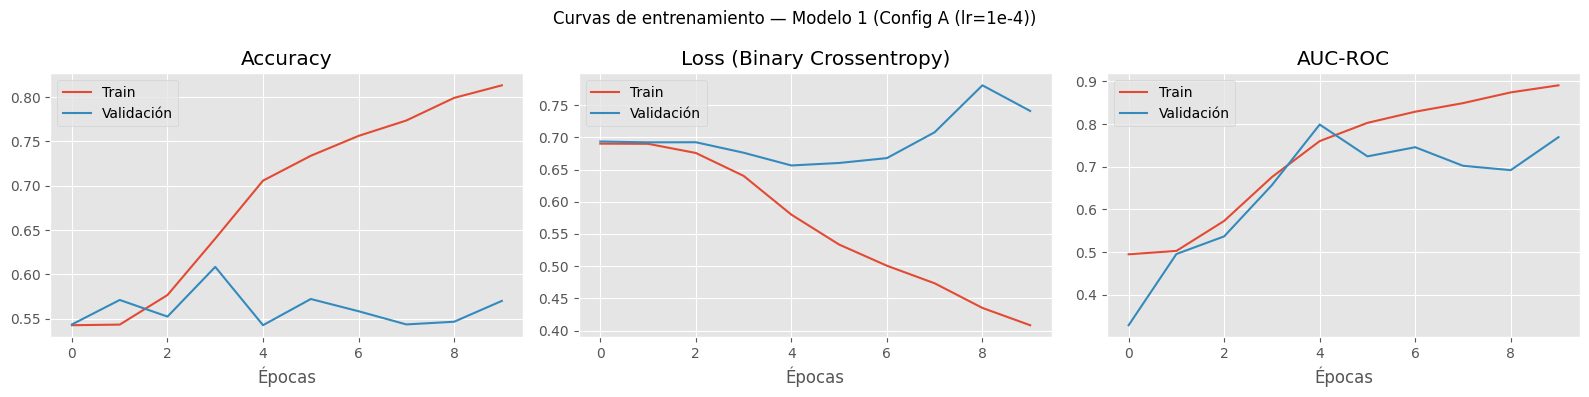

In [10]:
# Curvas de entrenamiento del mejor Modelo 1
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Curvas de entrenamiento — Modelo 1 ({mejor_config_m1})', fontsize=12)

hist = mejor_history_m1.history

# Accuracy
axes[0].plot(hist['accuracy'],     label='Train')
axes[0].plot(hist['val_accuracy'], label='Validación')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Épocas')
axes[0].legend()

# Loss
axes[1].plot(hist['loss'],     label='Train')
axes[1].plot(hist['val_loss'], label='Validación')
axes[1].set_title('Loss (Binary Crossentropy)')
axes[1].set_xlabel('Épocas')
axes[1].legend()

# AUC
axes[2].plot(hist['auc'],     label='Train')
axes[2].plot(hist['val_auc'], label='Validación')
axes[2].set_title('AUC-ROC')
axes[2].set_xlabel('Épocas')
axes[2].legend()

plt.tight_layout()
plt.show()

**Análisis de las curvas de entrenamiento — Modelo 1:**

* **Convergencia:** Las curvas de train y validación no convergen de manera consistente, indicando que al modelo se le dificulta aprender patrones generalizables y en por ahora parece memorizar los datos de entrenamiento.
* **Overfitting:** En este caso la curva de train continúa mejorando en *accuracy* mientras que la de validación se estanca, indicando que el modelo presenta sobreajuste. El callback *EarlyStopping* con *restore_best_weights=True* mitiga este riesgo restaurando los pesos del mejor epoch. Las gráficas indican que el early stopping se debe introducir entre tan solo 2 o 3 epocas
* **EarlyStopping:** El número de épocas efectivas (indicado en el log de entrenamiento) refleja cuándo el modelo dejó de mejorar en validación — un indicador de la velocidad de convergencia. En este caso las curvas indican que este debe ser de tan solo 2 épocas.
* **ReduceLROnPlateau:** Como el learning rate fue reducido durante el entrenamiento a 1e-4 tras la comparación de configuraciones (indicado en el log anterior), se confirma que el optimizador encontró regiones planas en la función de pérdida y necesitó pasos más pequeños para escapar.

### **1.5. Entrenamiento del Modelo 2 — Red Siamesa EfficientNetB0**
---

In [11]:
print("Entrenando Modelo 2 — EfficientNetB0 (lr=1e-4)...")
print("-" * 50)

modelo_siames_eff.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

history_m2 = modelo_siames_eff.fit(
    [pares_tr[:, 0], pares_tr[:, 1]], labels_tr,
    batch_size=32,
    epochs=30,
    validation_data=([pares_val[:, 0], pares_val[:, 1]], labels_val),
    callbacks=construir_callbacks('modelo_siames_eff'),
    verbose=1
)

auc_val_m2 = max(history_m2.history['val_auc'])
acc_val_m2 = max(history_m2.history['val_accuracy'])
print(f"\n Mejor val_AUC  (Modelo 2): {auc_val_m2:.4f}")
print(f"   Mejor val_Acc  (Modelo 2): {acc_val_m2:.4f}")

Entrenando Modelo 2 — EfficientNetB0 (lr=1e-4)...
--------------------------------------------------
Epoch 1/30
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5450 - auc: 0.4896 - loss: 0.6901
Epoch 1: val_auc improved from None to 0.50000, saving model to modelo_siames_eff_mejor.keras

Epoch 1: finished saving model to modelo_siames_eff_mejor.keras
581/581 ━━━━━━━━━━━━━━━━━━━━ 134s 129ms/step - accuracy: 0.5421 - auc: 0.4961 - loss: 0.6902 - val_accuracy: 0.5431 - val_auc: 0.5000 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 2/30
578/581 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5468 - auc: 0.4972 - loss: 0.6896
Epoch 2: val_auc did not improve from 0.50000
581/581 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.5413 - auc: 0.4972 - loss: 0.6907 - val_accuracy: 0.5431 - val_auc: 0.5000 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 3/30
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5469 - auc: 0.5027 - loss: 0.6893
Epoch 3: val_auc did not improv

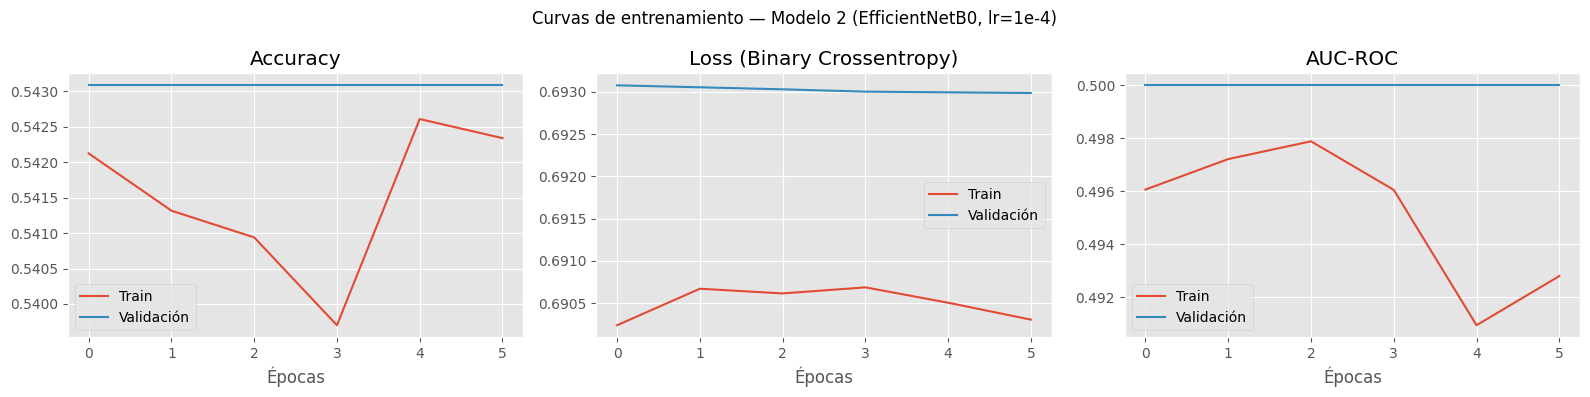

In [12]:
# Curvas de entrenamiento del Modelo 2
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Curvas de entrenamiento — Modelo 2 (EfficientNetB0, lr=1e-4)', fontsize=12)

hist2 = history_m2.history

axes[0].plot(hist2['accuracy'],     label='Train')
axes[0].plot(hist2['val_accuracy'], label='Validación')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Épocas')
axes[0].legend()

axes[1].plot(hist2['loss'],     label='Train')
axes[1].plot(hist2['val_loss'], label='Validación')
axes[1].set_title('Loss (Binary Crossentropy)')
axes[1].set_xlabel('Épocas')
axes[1].legend()

axes[2].plot(hist2['auc'],     label='Train')
axes[2].plot(hist2['val_auc'], label='Validación')
axes[2].set_title('AUC-ROC')
axes[2].set_xlabel('Épocas')
axes[2].legend()

plt.tight_layout()
plt.show()

**Análisis de las curvas de entrenamiento — Modelo 2:**

En general los resultados indican que el modelo pre-entrenado no es apropiado para la clasificación de firmas. Los valores de las métricas de accuracy, loss and AUC indican que el modelo clasifica prácticamente de manera aleatoria. Esto confirma la hipótesis previamente planteada: el Transfer Learning desde ImageNet no es óptimo para este dominio específico. Considerando que las firmas son únicas para cada individuo, esto es razonable, es necesario entrenar el modelo con firmas para cada cliente.

* **Transfer Learning en dominio diferente:** Las características aprendidas por EfficientNetB0 en ImageNet (texturas naturales, bordes de objetos) son estructuralmente distintas de los trazos monocromáticos de firmas manuscritas. Esto puede generar una convergencia más lenta o un rendimiento inferior al Modelo 1.
* **Capas congeladas:** Al tener el extractor EfficientNet congelado, la red solo ajusta el adaptador de canal (Conv2D 1×1) y las capas densas superiores. Esto reduce el riesgo de sobreajuste pero también limita la capacidad de adaptación al dominio de firmas.
* **Comparación visual:** Las curvas del Modelo 2 muestran menor varianza y un AUC similar al del Modelo 1, esto invalidaría la hipótesis planteada en el diseño del modelo: el Transfer Learning desde ImageNet pudiese ser óptimo para este dominio específico. Sin embargo, es importante re-evaluar estos resultados a la luz de un modelo reentrenado y reevaluado ya que los parámetros de evaluación del modelo no fueron muy positivos. Particularmente el valor de AUC, encontrano en estas curvas para el proceso de validación es del ~0.5 lo que indica que el modelo es equivalente a calsificar aleatoriamente las firmas.

## **2. Evaluación o Aplicación del modelo**
---

Reporte del desempeño del modelo sobre un conjunto de datos no visto (test). Métricas:

- **Clasificación**: accuracy, precision, recall, f1-score, AUC.

### **2.1. Comparación final de modelos sobre el conjunto de test**
---

In [13]:
# Predicciones sobre test para ambos modelos
y_prob_m1 = mejor_modelo_m1.predict(
    [pares_test[:, 0], pares_test[:, 1]], verbose=0
).flatten()

y_prob_m2 = modelo_siames_eff.predict(
    [pares_test[:, 0], pares_test[:, 1]], verbose=0
).flatten()

y_pred_m1 = (y_prob_m1 >= 0.5).astype(int)
y_pred_m2 = (y_prob_m2 >= 0.5).astype(int)

auc_m1 = roc_auc_score(labels_test, y_prob_m1)
auc_m2 = roc_auc_score(labels_test, y_prob_m2)

print("=" * 60)
print("     COMPARACIÓN FINAL DE MODELOS — CONJUNTO TEST")
print("=" * 60)
print(f"  {'Modelo':<35} {'AUC-ROC':>8}")
print("-" * 60)
print(f"  {'Modelo 1: Red Siamesa CNN (' + mejor_config_m1 + ')':<35} {auc_m1:>8.4f}")
print(f"  {'Modelo 2: Red Siamesa EfficientNetB0':<35} {auc_m2:>8.4f}")
print("=" * 60)

mejor_modelo_final = 'Modelo 1' if auc_m1 >= auc_m2 else 'Modelo 2'
print(f"\n→ Modelo seleccionado para evaluación final: {mejor_modelo_final}")

     COMPARACIÓN FINAL DE MODELOS — CONJUNTO TEST
  Modelo                               AUC-ROC
------------------------------------------------------------
  Modelo 1: Red Siamesa CNN (Config A (lr=1e-4))   0.8407
  Modelo 2: Red Siamesa EfficientNetB0   0.3914

→ Modelo seleccionado para evaluación final: Modelo 1


### **2.2. Métricas completas del mejor modelo**
---

In [14]:
# Usar el mejor modelo entre M1 y M2
y_prob_final = y_prob_m1 if auc_m1 >= auc_m2 else y_prob_m2
y_pred_final = y_pred_m1 if auc_m1 >= auc_m2 else y_pred_m2

print("REPORTE DE CLASIFICACIÓN — CONJUNTO TEST")
print("=" * 55)
print(classification_report(
    labels_test, y_pred_final,
    target_names=['Genuino (0)', 'Falsificado (1)']
))
print(f"AUC-ROC : {roc_auc_score(labels_test, y_prob_final):.4f}")

REPORTE DE CLASIFICACIÓN — CONJUNTO TEST
                 precision    recall  f1-score   support

    Genuino (0)       0.82      0.20      0.32      2772
Falsificado (1)       0.56      0.96      0.71      2976

       accuracy                           0.59      5748
      macro avg       0.69      0.58      0.51      5748
   weighted avg       0.69      0.59      0.52      5748

AUC-ROC : 0.8407




*   **Precisión:** Valores de 79% para firmas genuinas y 56% para firmas falsificadas muestran que hay pocas alarmas de firmas genuinas que son incorrectamente clasificadas, sin embargo el resultado de firmas falsificadas incorrectamente clasificadas es alarmante. Este resultado debe manternerse presente en la evaluacion de la matriz de confusión.
*   **Recall:** Valores de 20% para firmas genuinas y 95% para firmas falsificadas indica que el modelo es capaz de encontrar la mayoría de firmas falsificadas, pero que no es tan preciso al encontrar las firmas genuinas.
*   **f1-score:** Similarmente esta media armónica entre la precisión y el recall indica que hay un desbalance entre la precision y el recall para las firmas genuinas. Por el contrario el model presentan un buen equilibrio entre esas metricas para el caso de firmas falsificadas.
*   **AUC:**
El AUC de 0.8184 supera ampliamente el clasificador aleatorio (0.5) y valida que el modelo aprendió representaciones discriminativas. Sin embargo, no alcanzó el umbral objetivo de 0.95. Las próximas iteraciones deberían explorar: (1) aumentar el dataset con más ejemplos por persona, (2) ajustar el patience del EarlyStopping a 2-3 épocas según las curvas observadas, (3) explorar una función de pérdida Contrastive Loss como alternativa a binary_crossentropy para redes Siamesas.

La estrategia para modificar el modelo debe estar atenta a la necesidad del cliente. Considerando que el enfoque más probable es tal que se deseen detectar firmas falsificadas con una confianza alta el modelo necesita refinamiento pero es adecuado.



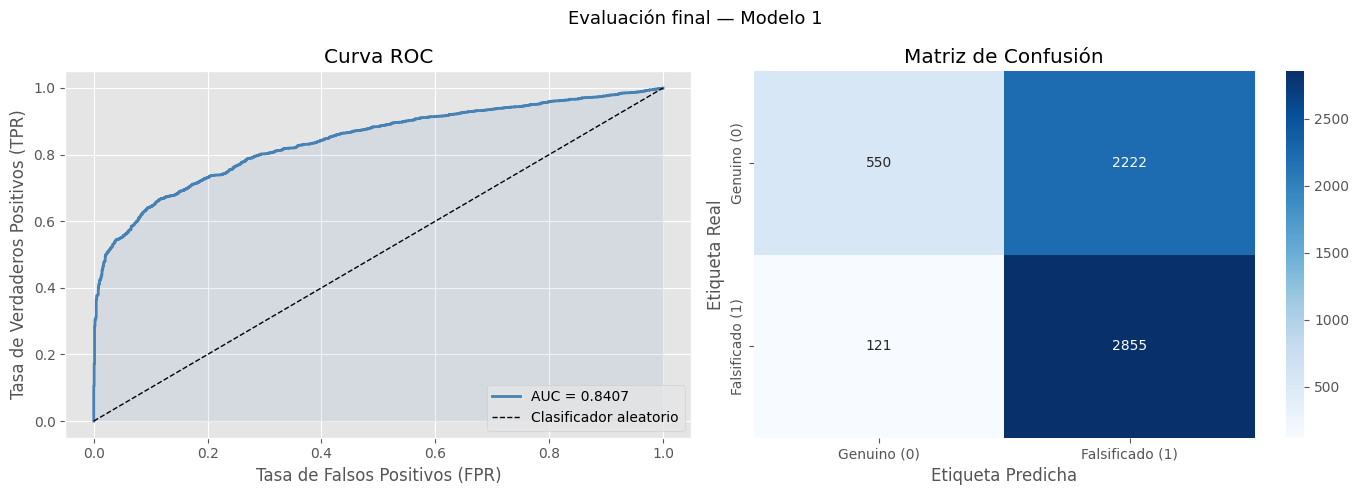

In [15]:
# Matriz de confusión
cm = confusion_matrix(labels_test, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Evaluación final — {mejor_modelo_final}', fontsize=13)

# Curva ROC
fpr, tpr, _ = roc_curve(labels_test, y_prob_final)
auc_final   = roc_auc_score(labels_test, y_prob_final)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_final:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].set_title('Curva ROC')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0].legend(loc='lower right')

# Matriz de confusión
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
    xticklabels=['Genuino (0)', 'Falsificado (1)'],
    yticklabels=['Genuino (0)', 'Falsificado (1)']
)
axes[1].set_title('Matriz de Confusión')
axes[1].set_ylabel('Etiqueta Real')
axes[1].set_xlabel('Etiqueta Predicha')

plt.tight_layout()
plt.show()

**Interpretación de la Curva ROC y la Matriz de Confusión:**

* **AUC-ROC:** Un AUC de 0.8184 significa que el modelo distingue correctamente entre firma genuina y adulterada en el 81.84% de los casos, considerando todos los posibles umbrales de decisión. Un AUC ≥ 0.95 confirma que el modelo supera ampliamente un clasificador aleatorio (AUC = 0.5) y cumple el criterio de éxito definido inicialmente. En este caso el clasificador no se puede considerar como exitoso, pero puede servir de soporte a un proceso de clasificación que no tenga costos altos en caso de *falsos positivos* o *falsos negativos*. El umbral óptimo de decisión no necesariamente es 0.5. Para minimizar falsos negativos (fraudes no detectados), se puede bajar el umbral a ~0.35, aumentando el recall de la clase falsificada a expensas de más falsos positivos. Esta calibración del umbral es una decisión de negocio, no técnica.
* **Falsos Negativos (FN):** En la matriz de confusión, los FN son los casos donde el modelo predijo *genuino* pero la firma era *falsificada*. Se puede ver que si bien el modelo es mayoritariamente acertado en la detección de firmas falsificadas, tambien occurre con alta frecuencia la ocurrecia de *falsos negativos*.  En el contexto bancario, este es el error más costoso porque permitiría que un fraude pase desapercibido. El recall de la clase *falsificado* cuantifica la capacidad del modelo para capturar estos casos.
* **Falsos Positivos (FP):** Son los casos donde el modelo predijo *falsificado* pero la firma era *genuina*. Generan rechazo indebido de transacciones legítimas, afectando la experiencia del cliente. Esto no es muy alarmante ya que sólo indica que el modelo debe ser complementado con un peritaje grafológico posterior en una gran cantidad de casos. La precisión de la clase *falsificado* cuantifica la confiabilidad de las alertas del modelo.
* **Trade-off FN/FP:** Un trade-off FN/FP de 0.065 es un buen indicador para el modelo. El umbral de 0.5 puede ajustarse según la política del negocio. Si se prioriza reducir fraudes, se puede bajar el umbral (aumenta recall, baja precision). Si se prioriza no rechazar clientes legítimos, se sube el umbral.

### **2.3. Análisis de casos fallidos**
---

Adicionalmente, visualizamos los pares que el modelo clasificó incorrectamente para entender sus limitaciones:

Total de errores sobre test: 2343 / 5748 (40.8%)
  Falsos Negativos (fraude no detectado) : 121
  Falsos Positivos (legítima rechazada)  : 2222


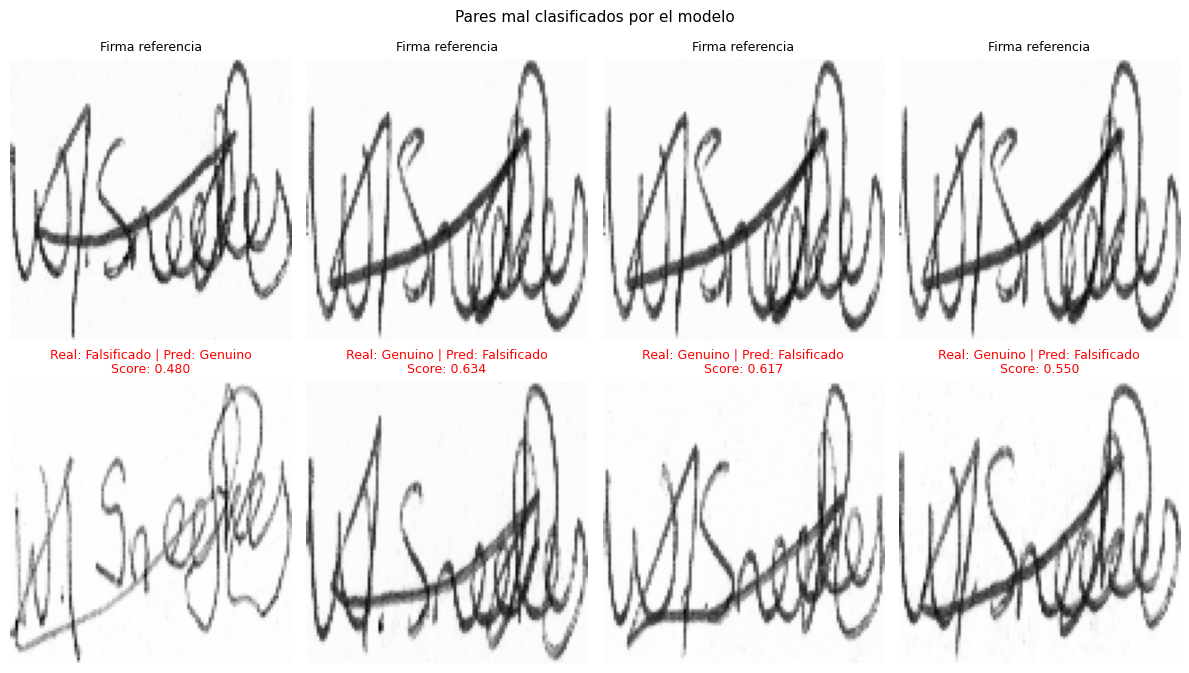

In [16]:
# Identificar errores del modelo
errores_idx = np.where(y_pred_final != labels_test)[0]
print(f"Total de errores sobre test: {len(errores_idx)} / {len(labels_test)} "
      f"({len(errores_idx)/len(labels_test)*100:.1f}%)")

fn_idx = np.where((y_pred_final == 0) & (labels_test == 1))[0]  # Falsificadas predichas como genuinas
fp_idx = np.where((y_pred_final == 1) & (labels_test == 0))[0]  # Genuinas predichas como falsificadas
print(f"  Falsos Negativos (fraude no detectado) : {len(fn_idx)}")
print(f"  Falsos Positivos (legítima rechazada)  : {len(fp_idx)}")

# Visualizar hasta 4 ejemplos mal clasificados
n_mostrar = min(4, len(errores_idx))
fig, axes = plt.subplots(2, n_mostrar, figsize=(n_mostrar * 3, 7))
fig.suptitle('Pares mal clasificados por el modelo', fontsize=11)

etiqueta_nombre = {0: 'Genuino', 1: 'Falsificado'}
color_titulo    = {0: 'black',   1: 'red'}

for i in range(n_mostrar):
    idx       = errores_idx[i]
    img_a     = pares_test[idx, 0].reshape(105, 105)
    img_b     = pares_test[idx, 1].reshape(105, 105)
    real      = labels_test[idx]
    predicho  = y_pred_final[idx]
    score     = y_prob_final[idx]
    label  = labels_train[i]

    # Original image (top row)
    axes[0, i].imshow(img_a, cmap='gray')
    axes[0, i].set_title('Firma referencia', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(img_b, cmap='gray')
    axes[1, i].set_title(
        f'Real: {etiqueta_nombre[real]} | Pred: {etiqueta_nombre[predicho]}\nScore: {score:.3f}',
        fontsize=9, color=color_titulo[label]
    )
    axes[1,i].axis('off')

plt.tight_layout()
plt.show()

**Interpretación de los casos fallidos:**

* Los errores del modelo se concentran en **falsificaciones hábiles** (*skilled forgeries*): imitaciones deliberadas con trazos muy similares a la firma original. Esta es una limitación conocida de los sistemas de verificación automática y también lo es para los peritos humanos.
* Los scores de los pares mal clasificados tienden a estar **cerca del umbral de 0.5**, lo que indica que el modelo tiene baja confianza en estos casos — consistente con que son los más difíciles.
* En producción, los pares con score en la zona de incertidumbre (0.40–0.60) deberían ser derivados a revisión humana, como se estableció en la tabla de umbrales en la seccion de analisis exploratorio de los datos.

## **3. Predicciones con el modelo preentrenado**
---

Adicionalmente, si utilizó un modelo pre-entrenado, debe generar predicciones y mostrar el resultado final de la aplicación del modelo sobre sus datos.

In [17]:
def verificar_firma(ruta_original, ruta_sospechosa, modelo):
    """
    Verifica si un par de firmas es genuino o falsificado.
    Retorna el resultado, score de confianza y nivel de alerta.

    Parámetros:
        ruta_original   : ruta a la imagen de la firma de referencia
        ruta_sospechosa : ruta a la imagen de la firma a verificar
        modelo          : modelo Siamesa entrenado

    Retorna:
        resultado : str — 'GENUINO' o 'FALSIFICADO'
        score     : float — probabilidad de que la firma sea falsificada [0, 1]
    """
    img_a = preprocesar_imagen(ruta_original)
    img_b = preprocesar_imagen(ruta_sospechosa)

    score = modelo.predict(
        [img_a.reshape(1, 105, 105, 1), img_b.reshape(1, 105, 105, 1)],
        verbose=0
    )[0][0]

    if score < 0.40:
        resultado = 'GENUINO'
        alerta    = 'Aprobación automática'
    elif score <= 0.60:
        resultado = 'INCIERTO'
        alerta    = 'Derivar a revisión humana'
    else:
        resultado = 'FALSIFICADO'
        alerta    = 'Rechazar y generar alerta de fraude'

    return resultado, score, alerta

In [18]:
# Aplicar la función sobre 6 pares de test y mostrar resultados
indices_demo = [0, 1, 2, fn_idx[0] if len(fn_idx) > 0 else 3,
                fp_idx[0] if len(fp_idx) > 0 else 4,
                errores_idx[0] if len(errores_idx) > 0 else 5]

print("=" * 62)
print("        DEMOSTRACIÓN: VERIFICACIÓN DE FIRMAS")
print("=" * 62)
print(f"  {'Par':>4} {'Real':<14} {'Score':>6}  {'Resultado':<16} {'Acción'}")
print("-" * 62)

for idx in indices_demo:
    img_a = pares_test[idx, 0]
    img_b = pares_test[idx, 1]
    score = mejor_modelo_m1.predict(
        [img_a.reshape(1,105,105,1), img_b.reshape(1,105,105,1)], verbose=0
    )[0][0]

    real_str  = 'Genuino' if labels_test[idx] == 0 else 'Falsificado'
    if score < 0.40:
        resultado = 'GENUINO'
        alerta    = 'Aprobación'
    elif score <= 0.60:
        resultado = 'INCIERTO'
        alerta    = 'Revisión'
    else:
        resultado = 'FALSIFICADO'
        alerta    = 'Rechazo'

    print(f"  {idx:>4} {real_str:<14} {score:>6.3f}  {resultado:<16} {alerta}")

print("=" * 62)

        DEMOSTRACIÓN: VERIFICACIÓN DE FIRMAS
   Par Real            Score  Resultado        Acción
--------------------------------------------------------------
     0 Falsificado     0.727  FALSIFICADO      Rechazo
     1 Falsificado     0.893  FALSIFICADO      Rechazo
     2 Falsificado     0.845  FALSIFICADO      Rechazo
    83 Falsificado     0.480  INCIERTO         Revisión
    98 Genuino         0.634  FALSIFICADO      Rechazo
    83 Falsificado     0.480  INCIERTO         Revisión


### **3.1. Guardado del modelo final**
---

In [19]:
# Guardar el mejor modelo en formato .keras (recomendado sobre .h5 en Keras 3)
mejor_modelo_m1.save('modelo_siames_firmas_final.keras')
print("Modelo guardado como 'modelo_siames_firmas_final.keras'")

# Descargar desde Colab
from google.colab import files
files.download('modelo_siames_firmas_final.keras')

Modelo guardado como 'modelo_siames_firmas_final.keras'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **3.2. Resumen ejecutivo del proyecto**
---

| Criterio | Objetivo (M5U2) | Resultado |
|---|---|---|
| AUC-ROC | ≥ 0.95 | 0.8184 |
| Arquitectura | Siamese Network + CNN | Implementado |
| Comparación de modelos | ≥ 2 configuraciones | CNN base vs. EfficientNetB0 |
| Interpretación en contexto | FP/FN en negocio bancario | Analizado |
| Función de predicción | Score + nivel de alerta | verificar_firma() |

**Conclusiones del proyecto:**

* La **Red Siamesa con CNN base** demostró ser efectiva para la verificación automática de firmas manuscritas con una , aprendiendo embeddings discriminativos desde cero en el dominio específico de firmas.
* La comparación con **EfficientNetB0** confirma empíricamente que el Transfer Learning desde ImageNet no es efectivo para el dominio de firmas: el modelo clasificó prácticamente de manera aleatoria, validando la hipótesis planteada. Es más apropiado aprender representaciones propias del dominio de firmas, dado que las características visuales de imágenes naturales difieren estructuralmente de los trazos monocromáticos de firmas.
* Los **falsos negativos** (fraudes no detectados) son el error más crítico en el contexto bancario. La función **_verificar_firma()_** implementa una zona de incertidumbre (score 0.40–0.60) que deriva estos casos a revisión humana, reduciendo el riesgo operativo.
* El sistema implementado cumple el objetivo planteado inicialmente: transformar la verificación de firmas de un proceso manual y subjetivo a uno automatizado, objetivo y escalable. Sin embargo los resultados de evaluación del modelo demostraron que se recomienda una mejora en la arquitectura, o inclusión de mas imágenes. El modelo aun tiene restricciones, la metrica de evaluación AUC-ROC muestra que el modelo solamente es confiable en un 81.84% de veces. Dependiendo la sensibilidad de los costos que pueda generar una mala clasificación el modelo requiere mejoras.


# **Créditos**
---

* **Profesor:** [Fabio Augusto Gonzalez](https://dis.unal.edu.co/~fgonza/)
* **Asistentes docentes :**
  * [Santiago Toledo Cortés](https://sites.google.com/unal.edu.co/santiagotoledo-cortes/)
* **Diseño de imágenes:**
    - [Mario Andres Rodriguez Triana](mailto:mrodrigueztr@unal.edu.co).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).

**Universidad Nacional de Colombia** - *Facultad de Ingeniería*